<div style="background-color:RGB(0,114,200);">
<h1 style="margin:auto;padding:20px 0;color:#fff;text-align:center">PROJET 4 – DATA ANALYST</h1>
<h2 style="margin:auto;padding:10px 0 20px;color:#fff;text-align:center">Étude de santé publique – Sous-nutrition mondiale</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques


<div style="background-color:RGB(0,150,250);">
<h2 style="margin:auto;padding:20px;color:#fff;">Étape 1 – Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">1.1 – Importation des librairies</h3>
</div>

In [ ]:
#pip install pandas  numpy matplotlib  seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">1.2 – Chargement des fichiers</h3>
</div>

In [ ]:
population        = pd.read_csv("population.csv")
dispo_alimentaire = pd.read_csv("dispo_alimentaire.csv")
aide_alimentaire  = pd.read_csv("aide_alimentaire.csv")
sous_nutrition    = pd.read_csv("sous_nutrition.csv")
print("✅ Fichiers chargés avec succès.")

✅ Fichiers chargés avec succès.


<div style="background-color:RGB(0,150,250);">
<h2 style="margin:auto;padding:20px;color:#fff;">Étape 2 – Analyse exploratoire & préparation des données</h2>
</div>

<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">2.1 – Fichier population</h3>
</div>

In [ ]:
print(f"Dimensions : {population.shape[0]} lignes × {population.shape[1]} colonnes")
population.info()
population.head()

Dimensions : 1416 lignes × 3 colonnes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB


,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [ ]:
# Harmonisation : valeurs en milliers → unités réelles
population["Valeur_harmonisee"] = population["Valeur"] * 1_000
population = population.rename(columns={"Valeur": "Population"})
population["Année"] = population["Année"].astype(int)
print("✅ Colonne Valeur_harmonisee créée et Année convertie en entier.")
population.head()

✅ Colonne Valeur_harmonisee créée et Année convertie en entier.


,Zone,Année,Population,Valeur_harmonisee
0,Afghanistan,2013,32269.589,32269589.0
1,Afghanistan,2014,33370.794,33370794.0
2,Afghanistan,2015,34413.603,34413603.0
3,Afghanistan,2016,35383.032,35383032.0
4,Afghanistan,2017,36296.113,36296113.0


<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">2.2 – Fichier disponibilité alimentaire</h3>
</div>

In [ ]:
print(f"Dimensions : {dispo_alimentaire.shape[0]} lignes × {dispo_alimentaire.shape[1]} colonnes")
dispo_alimentaire.info()
dispo_alimentaire.head()

Dimensions : 15605 lignes × 18 colonnes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15605 entries, 0 to 15604
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Zone                                                           15605 non-null  object 
 1   Produit                                                        15605 non-null  object 
 2   Origine                                                        15605 non-null  object 
 3   Aliments pour animaux                                          2720 non-null   float64
 4   Autres Utilisations                                            5496 non-null   float64
 5   Disponibilité alimentaire (Kcal/personne/jour)                 14241 non-null  float64
 6   Disponibilité alimentaire en quantité (kg/personne/an)         14015 non-null  float64
 7   Disponibilité de m

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Remplacement des NaN par 0
dispo_alimentaire = dispo_alimentaire.fillna(0)

# Conversion milliers de tonnes → kg
cols_kg = ["Disponibilité intérieure", "Exportations - Quantité","Aliments pour animaux",
           "Importations - Quantité", "Nourriture", "Pertes",
           "Production", "Semences", "Traitement", "Variation de stock"]
dispo_alimentaire[cols_kg] = dispo_alimentaire[cols_kg] * 1_000_000
print("✅ NaN remplacés, colonnes quantitatives converties en kg.")

✅ NaN remplacés, colonnes quantitatives converties en kg.


<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">2.3 – Fichier aide alimentaire</h3>
</div>

In [ ]:
print(f"Dimensions : {aide_alimentaire.shape[0]} lignes × {aide_alimentaire.shape[1]} colonnes")
aide_alimentaire.info()
aide_alimentaire.head()

Dimensions : 1475 lignes × 4 colonnes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Pays bénéficiaire  1475 non-null   object
 1   Année              1475 non-null   int64 
 2   Produit            1475 non-null   object
 3   Valeur             1475 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.2+ KB


,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [ ]:
# Harmonisation du nom de colonne + conversion tonnes → kg
aide_alimentaire = aide_alimentaire.rename(columns={"Pays bénéficiaire": "Zone"})
aide_alimentaire["Valeur"] = aide_alimentaire["Valeur"] * 1_000
print("✅ Colonne renommée, valeurs converties en kg.")
aide_alimentaire.head()

✅ Colonne renommée, valeurs converties en kg.


,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">2.4 – Fichier sous-nutrition</h3>
</div>

In [ ]:
print(f"Dimensions : {sous_nutrition.shape[0]} lignes × {sous_nutrition.shape[1]} colonnes")
sous_nutrition.info()
sous_nutrition.head()

Dimensions : 1218 lignes × 3 colonnes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Zone    1218 non-null   object
 1   Année   1218 non-null   object
 2   Valeur  624 non-null    object
dtypes: object(3)
memory usage: 28.7+ KB


,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [ ]:
#Conversion de la colonne sous nutrition en numérique
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])

ValueError: Unable to parse string "<0.1" at position 60

In [ ]:
# Conversion numérique + remplacement NaN + renommage + conversion en unités réelles
sous_nutrition["Valeur"] = pd.to_numeric(sous_nutrition["Valeur"], errors="coerce").fillna(0)
sous_nutrition = sous_nutrition.rename(columns={"Valeur": "Sous_nutrition"})
sous_nutrition["Sous_nutrition"] = sous_nutrition["Sous_nutrition"] * 1_000_000

# Décomposition de la plage annuelle (ex: "2016-2018") → année médiane
tmp = sous_nutrition["Année"].str.split("-", expand=True)
sous_nutrition["annee_mid"] = ((tmp[0].astype(int) + tmp[1].astype(int)) / 2).astype(int)
print("✅ Données sous-nutrition préparées.")
sous_nutrition.head()

✅ Données sous-nutrition préparées.


,Zone,Année,Sous_nutrition,annee_mid
0,Afghanistan,2012-2014,8600000.0,2013
1,Afghanistan,2013-2015,8800000.0,2014
2,Afghanistan,2014-2016,8900000.0,2015
3,Afghanistan,2015-2017,9700000.0,2016
4,Afghanistan,2016-2018,10500000.0,2017


<div style="background-color:RGB(0,150,250);">
<h2 style="margin:auto;padding:20px;color:#fff;">Étape 3 – Analyses thématiques</h2>
</div>

<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">3.1 – Proportion de personnes en sous-nutrition (2017)</h3>
</div>

In [ ]:
# Jointure population × sous-nutrition sur l'année médiane 2017
jointure = population.merge(
    sous_nutrition,
    left_on=["Zone", "Année"],
    right_on=["Zone", "annee_mid"],
    how="inner"
)
jointure_2017 = jointure[jointure["annee_mid"] == 2017].copy()

total_sous_nutri_2017 = jointure_2017["Sous_nutrition"].sum()
total_population_2017 = jointure_2017["Valeur_harmonisee"].sum()
prop_pct = total_sous_nutri_2017 / total_population_2017 * 100

print(f"Population mondiale 2017      : {total_population_2017:,.0f} personnes")
print(f"Personnes sous-alimentées 2017 : {total_sous_nutri_2017:,.0f} personnes")
print(f"Part de la population mondiale : {prop_pct:.2f} %")

Population mondiale 2017      : 7,543,798,779 personnes
Personnes sous-alimentées 2017 : 535,700,000 personnes
Part de la population mondiale : 7.10 %


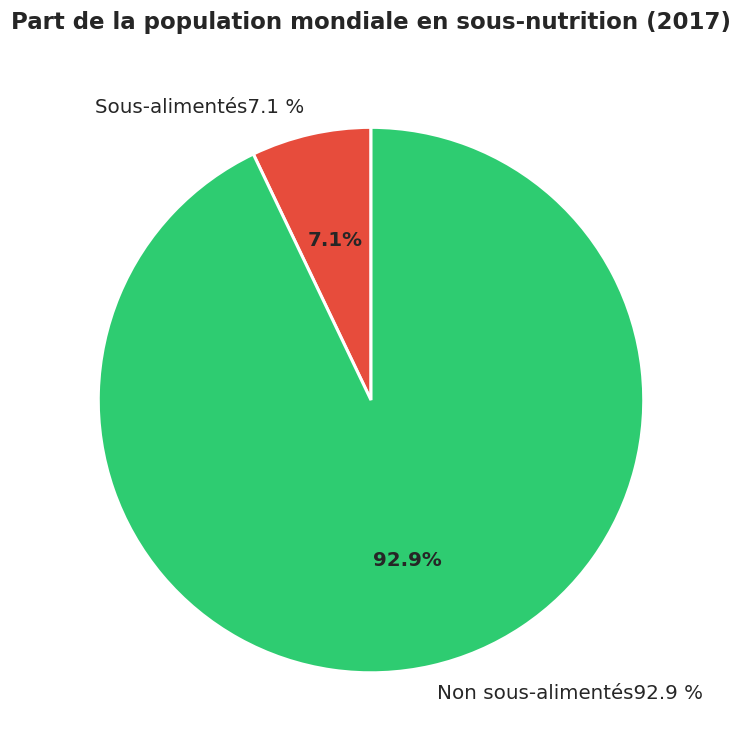

In [ ]:
# ── Graphique : proportion sous-nutrition vs reste de la population ──
fig, ax = plt.subplots(figsize=(7, 7))
values = [prop_pct, 100 - prop_pct]
labels = [f"Sous-alimentés{prop_pct:.1f} %", f"Non sous-alimentés{100-prop_pct:.1f} %"]
colors = ["#e74c3c", "#2ecc71"]
wedges, texts, autotexts = ax.pie(
    values, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 13}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight("bold")
ax.set_title("Part de la population mondiale en sous-nutrition (2017)",
             fontsize=15, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">3.2 – Nombre théorique de personnes pouvant être nourries (toutes sources)</h3>
</div>

In [ ]:
# Jointure dispo_alimentaire × population 2017
pop_2017 = population[population["Année"] == 2017].copy()
dispo_alimentaire_merge = dispo_alimentaire.merge(
    pop_2017[["Zone", "Population"]],
    on="Zone", how="left"
)
# Population en unités réelles
dispo_alimentaire_merge["Population"] = dispo_alimentaire_merge["Population"] * 1_000

# kcal disponibles total = kcal/personne/jour × population
dispo_alimentaire_merge["dispo_kcal"] = (
    dispo_alimentaire_merge["Disponibilité alimentaire (Kcal/personne/jour)"]
    * dispo_alimentaire_merge["Population"]
)
# 2 200 kcal/jour : apport calorique moyen recommandé
dispo_alimentaire_merge["Nb_nourries"] = dispo_alimentaire_merge["dispo_kcal"] / 2_200

total_nb_nourries  = dispo_alimentaire_merge["Nb_nourries"].sum()
population_mondiale = dispo_alimentaire_merge["Population"].sum()
ratio_pourcent = total_nb_nourries / total_population_2017 * 100

print(f"Nombre de personnes pouvant être nourries : {total_nb_nourries:,.0f}")
print(f"Population mondiale réelle                 : {total_population_2017:,.0f}")
print(f"Ratio                                      : {ratio_pourcent:.1f} %")

Nombre de personnes pouvant être nourries : 9,508,629,376
Population mondiale réelle                 : 7,543,798,779
Ratio                                      : 126.0 %


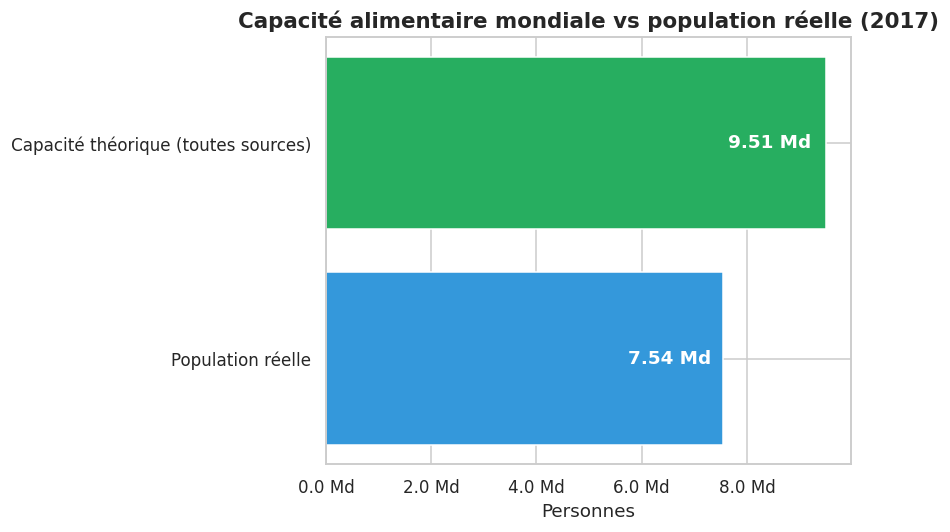

→ La production mondiale pourrait nourrir 126 % de la population réelle.


In [ ]:
# ── Graphique : capacité de nourrissage vs population réelle ──
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    ["Population réelle", "Capacité théorique (toutes sources)"],
    [total_population_2017, total_nb_nourries],
    color=["#3498db", "#27ae60"], edgecolor="white"
)
for bar in bars:
    w = bar.get_width()
    ax.text(w * 0.97, bar.get_y() + bar.get_height()/2,
            f"{w/1e9:.2f} Md", va="center", ha="right",
            color="white", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.1f} Md"))
ax.set_xlabel("Personnes", fontsize=12)
ax.set_title("Capacité alimentaire mondiale vs population réelle (2017)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"→ La production mondiale pourrait nourrir {ratio_pourcent:.0f} % de la population réelle.")

<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">3.3 – Nombre théorique de personnes nourries avec les produits végétaux uniquement</h3>
</div>

In [ ]:
dispo_vegetale = dispo_alimentaire_merge[
    dispo_alimentaire_merge["Origine"] == "vegetale"
].copy()

dispo_vegetale["dispo_kcal_vegetale"] = (
    dispo_vegetale["Disponibilité alimentaire (Kcal/personne/jour)"]
    * dispo_vegetale["Population"]
)
total_dispo_kcal_vegetale = dispo_vegetale["dispo_kcal_vegetale"].sum()
nb_pers_vegetaux = total_dispo_kcal_vegetale / 2_200
ratio_vegetaux_pct = nb_pers_vegetaux / total_population_2017 * 100

print(f"Capacité (végétaux seulement)  : {nb_pers_vegetaux:,.0f} personnes")
print(f"Pourcentage de la pop. mondiale : {ratio_vegetaux_pct:.1f} %")

Capacité (végétaux seulement)  : 7,845,801,914 personnes
Pourcentage de la pop. mondiale : 104.0 %


<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">3.4 – Répartition de la disponibilité intérieure mondiale</h3>
</div>

In [ ]:
colonnes_dispo = ["Aliments pour animaux", "Pertes", "Nourriture", "Traitement", "Semences"]
totaux = {col: dispo_alimentaire_merge[col].sum() for col in colonnes_dispo}

dispo_totale = dispo_alimentaire_merge["Disponibilité intérieure"].sum()
print(f"Disponibilité intérieure totale : {dispo_totale/1e12:.2f} milliers de milliards de kg")
for col, val in totaux.items():
    pct = val / dispo_totale * 100
    print(f"{col:30s}: {val/1e12:.2f} (soit {pct:.1f} % de la dispo intérieure)")

Disponibilité intérieure totale : 9.85 milliers de milliards de kg
Aliments pour animaux         : 1.30 (soit 13.2 % de la dispo intérieure)
Pertes                        : 0.45 (soit 4.6 % de la dispo intérieure)
Nourriture                    : 4.88 (soit 49.5 % de la dispo intérieure)
Traitement                    : 2.20 (soit 22.4 % de la dispo intérieure)
Semences                      : 0.15 (soit 1.6 % de la dispo intérieure)


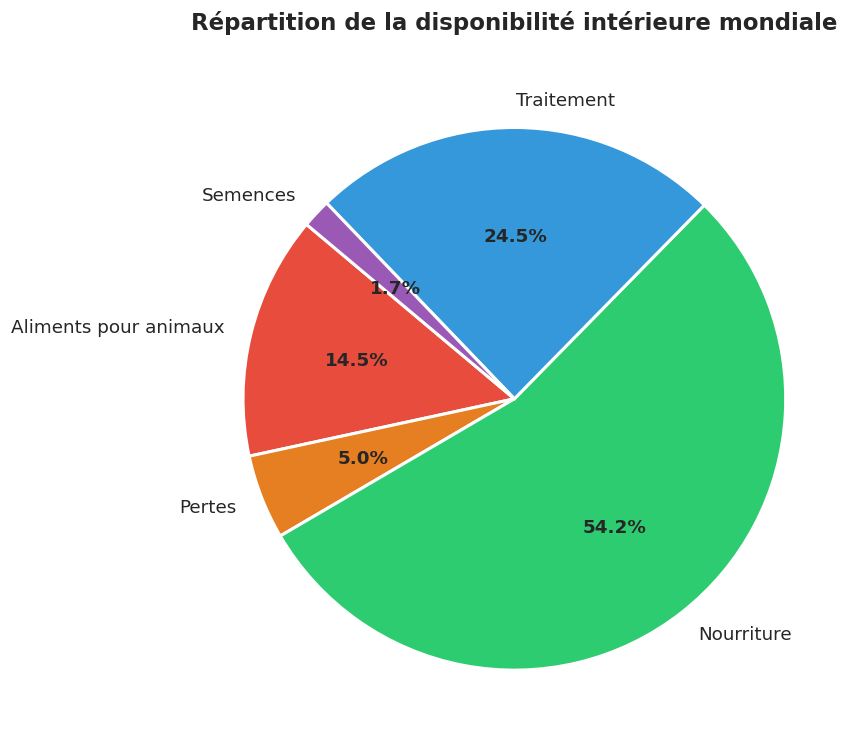

In [ ]:
# ── Graphique camembert : répartition disponibilité intérieure ──
fig, ax = plt.subplots(figsize=(8, 8))
colors_pie = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db", "#9b59b6"]
vals = list(totaux.values())
lbls = list(totaux.keys())
wedges, texts, autotexts = ax.pie(
    vals, labels=lbls, colors=colors_pie,
    autopct="%1.1f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")
ax.set_title("Répartition de la disponibilité intérieure mondiale",
             fontsize=15, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">3.5 – Utilisation des céréales : alimentation humaine vs animale</h3>
</div>

In [ ]:
liste_cereales = ["Blé", "Riz (Eq Blanchi)", "Orge", "Maïs", "Seigne","Avoine", "Millet", "Sorgho", "Céréales, Autres"]
dispo_cereales = dispo_alimentaire_merge.loc[dispo_alimentaire['Produit'].isin(liste_cereales),:].copy()
#cereales = dispo_alimentaire.loc[dispo_alimentaire['Produit'].isin(liste_cereales),:]
dispo_cereale_totale = dispo_cereales["Disponibilité intérieure"].sum()
print(f"Disponibilité intérieure totale : {dispo_cereale_totale/1e12:.2f} milliers de milliards de kg")
#Affichage de la proportion d'alimentation animale
print("Proportion d'alimentation animale :", "{:.2f}".format(dispo_cereales ['Aliments pour animaux'].sum()*100/dispo_cereales['Disponibilité intérieure'].sum()), "%")
print("Proportion Nourriture :", "{:.2f}".format(dispo_cereales ['Nourriture'].sum()*100/dispo_cereales['Disponibilité intérieure'].sum()), "%")

Disponibilité intérieure totale : 2.39 milliers de milliards de kg
Proportion d'alimentation animale : 36.20 %
Proportion Nourriture : 42.82 %


<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">3.6 – Top 10 pays avec la plus forte proportion de sous-nutrition (2017)</h3>
</div>

In [ ]:
sous_nut_2017 = sous_nutrition[sous_nutrition["Année"] == "2016-2018"].copy()
pop_2017_bis  = population[population["Année"] == 2017].copy()

df_sousnut_pop = sous_nut_2017.merge(
    pop_2017_bis[["Zone", "Valeur_harmonisee"]],
    on="Zone", how="inner"
)
df_sousnut_pop["prop_sous_nutrition"] = (
    df_sousnut_pop["Sous_nutrition"] / df_sousnut_pop["Valeur_harmonisee"] * 100
).round(1)

top10_pays_sous_nut = df_sousnut_pop.nlargest(10, "prop_sous_nutrition")[
    ["Zone", "prop_sous_nutrition", "Sous_nutrition", "Valeur_harmonisee"]
].reset_index(drop=True)

top10_pays_sous_nut.columns = ["Pays", "Proportion (%)", "Personnes sous-nourries", "Population"]
top10_pays_sous_nut

,Pays,Proportion (%),Personnes sous-nourries,Population
0,Haïti,48.3,5300000.0,10982366.0
1,République populaire démocratique de Corée,47.2,12000000.0,25429825.0
2,Madagascar,41.1,10500000.0,25570512.0
3,Libéria,38.3,1800000.0,4702226.0
4,Lesotho,38.2,800000.0,2091534.0
5,Tchad,38.0,5700000.0,15016753.0
6,Rwanda,35.1,4200000.0,11980961.0
7,Mozambique,32.8,9400000.0,28649018.0
8,Timor-Leste,32.2,400000.0,1243258.0
9,Afghanistan,28.9,10500000.0,36296113.0


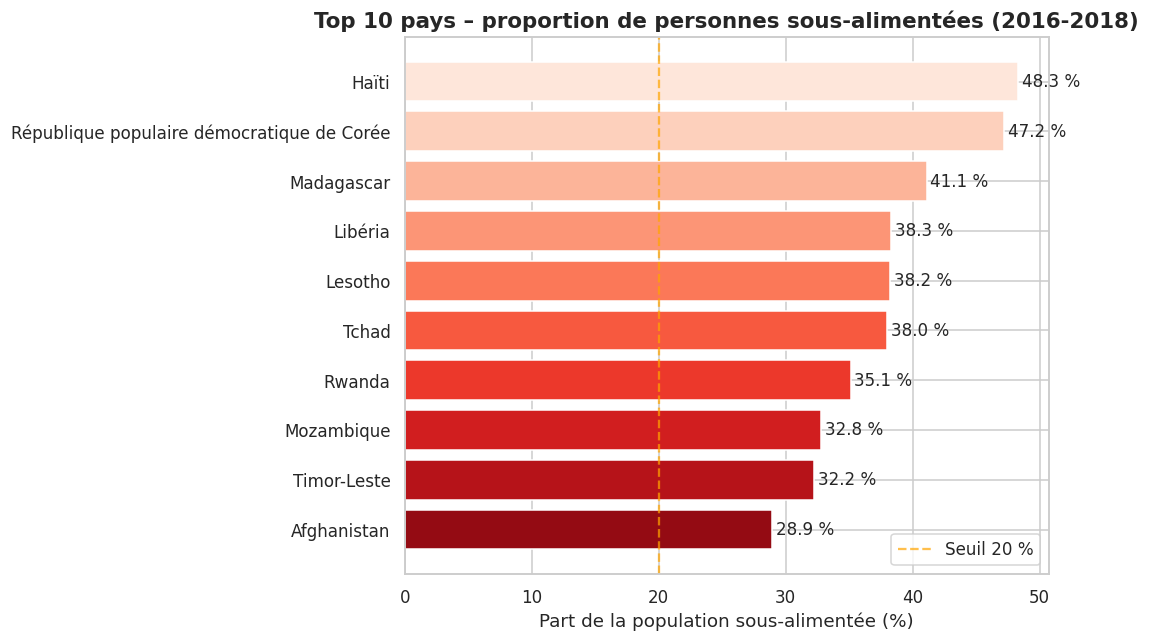

In [ ]:
# ── Graphique : top 10 pays sous-nutrition ──
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("Reds_r", 10)
df_plot = top10_pays_sous_nut.sort_values("Proportion (%)")
bars = ax.barh(df_plot["Pays"], df_plot["Proportion (%)"], color=palette, edgecolor="white")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f"{w:.1f} %", va="center", fontsize=11)
ax.set_xlabel("Part de la population sous-alimentée (%)", fontsize=12)
ax.set_title("Top 10 pays – proportion de personnes sous-alimentées (2016-2018)",
             fontsize=14, fontweight="bold")
ax.axvline(20, color="orange", linestyle="--", alpha=0.7, label="Seuil 20 %")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">3.7 – Top 10 pays bénéficiaires de l'aide alimentaire (depuis 2013)</h3>
</div>

In [ ]:
aide_depuis_2013 = aide_alimentaire[aide_alimentaire["Année"] >= 2013].copy()

aide_total_par_pays = (
    aide_depuis_2013
    .groupby("Zone", as_index=False)["Valeur"]
    .sum()
    .sort_values("Valeur", ascending=False)
)
top10_aide = aide_total_par_pays.head(10).reset_index(drop=True)
top10_aide.columns = ["Pays", "Aide reçue (kg)"]
top10_aide

,Pays,Aide reçue (kg)
0,République arabe syrienne,1858943000
1,Éthiopie,1381294000
2,Yémen,1206484000
3,Soudan du Sud,695248000
4,Soudan,669784000
5,Kenya,552836000
6,Bangladesh,348188000
7,Somalie,292678000
8,République démocratique du Congo,288502000
9,Niger,276344000


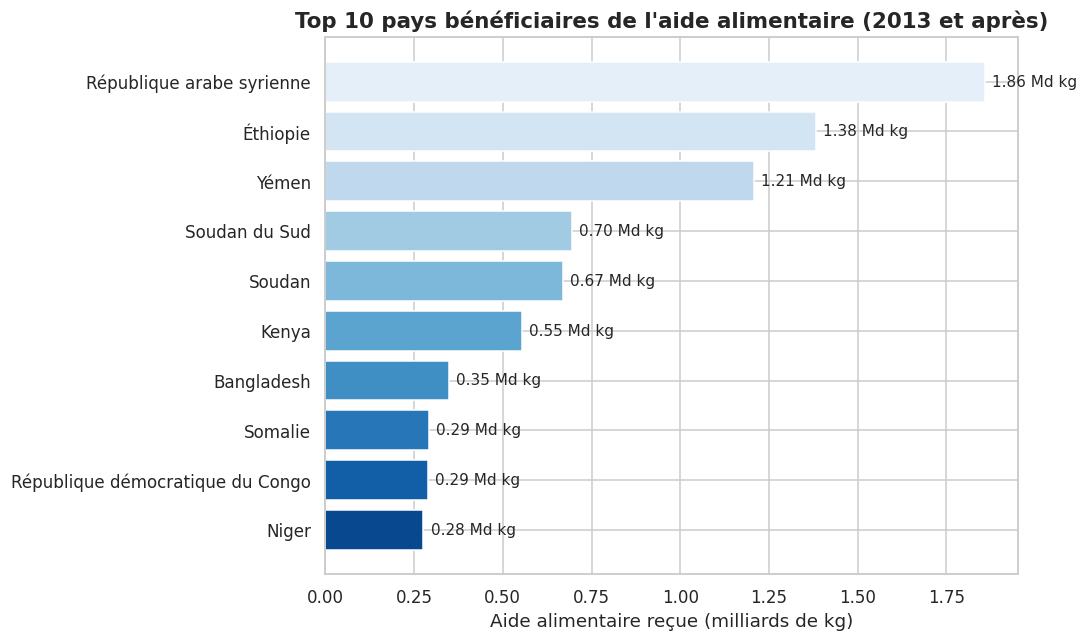

In [ ]:
# ── Graphique : top 10 pays bénéficiaires ──
fig, ax = plt.subplots(figsize=(10, 6))
palette_b = sns.color_palette("Blues_r", 10)
df_plot_aide = top10_aide.sort_values("Aide reçue (kg)")
bars = ax.barh(df_plot_aide["Pays"], df_plot_aide["Aide reçue (kg)"] / 1e9,
               color=palette_b, edgecolor="white")
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.02, bar.get_y() + bar.get_height()/2,
            f"{w:.2f} Md kg", va="center", fontsize=10)
ax.set_xlabel("Aide alimentaire reçue (milliards de kg)", fontsize=12)
ax.set_title("Top 10 pays bénéficiaires de l'aide alimentaire (2013 et après)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">3.8 – Évolution de l'aide pour les 5 pays les plus aidés (2013–2016)</h3>
</div>

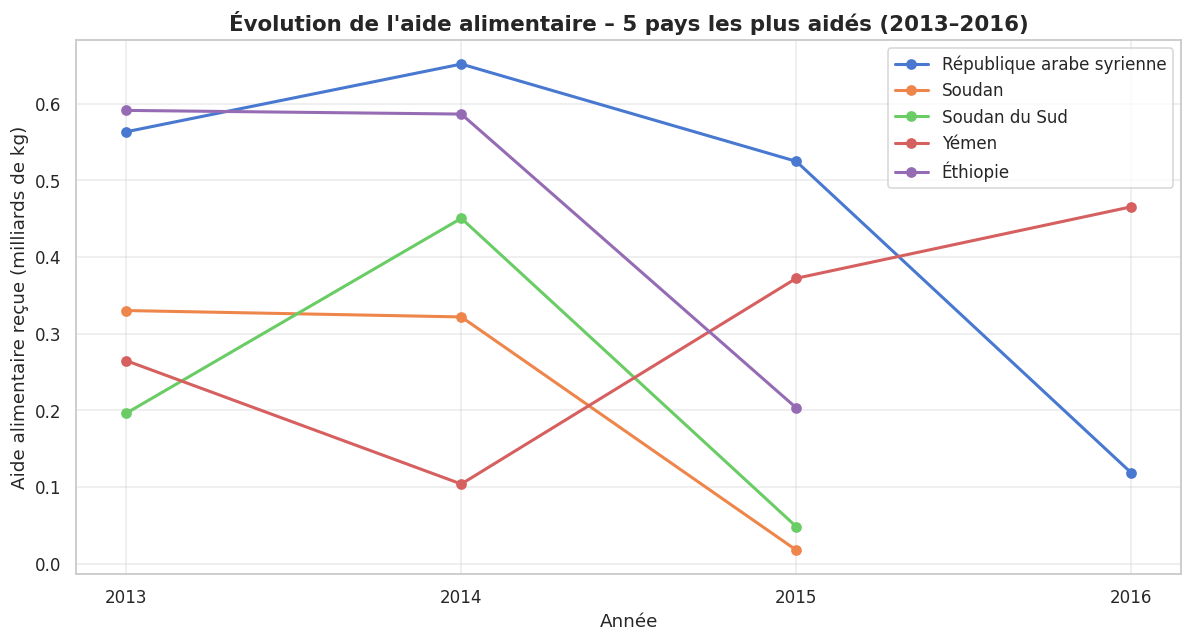

In [ ]:
aide_2013_2016 = aide_alimentaire[
    (aide_alimentaire["Année"] >= 2013) &
    (aide_alimentaire["Année"] <= 2016)
].copy()

top5_pays = (
    aide_2013_2016.groupby("Zone")["Valeur"].sum()
    .nlargest(5).index.tolist()
)

aide_top5_par_an = (
    aide_2013_2016[aide_2013_2016["Zone"].isin(top5_pays)]
    .groupby(["Zone", "Année"], as_index=False)["Valeur"]
    .sum()
    .rename(columns={"Valeur": "Aide_alimentaire"})
)

fig, ax = plt.subplots(figsize=(11, 6))
for pays, df_pays in aide_top5_par_an.groupby("Zone"):
    ax.plot(df_pays["Année"], df_pays["Aide_alimentaire"] / 1e9,
            marker="o", linewidth=2, label=pays)

ax.set_xticks(sorted(aide_top5_par_an["Année"].unique()))
ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("Aide alimentaire reçue (milliards de kg)", fontsize=12)
ax.set_title("Évolution de l'aide alimentaire – 5 pays les plus aidés (2013–2016)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">3.9 & 3.10 – Pays avec le moins / le plus de disponibilité alimentaire par habitant</h3>
</div>

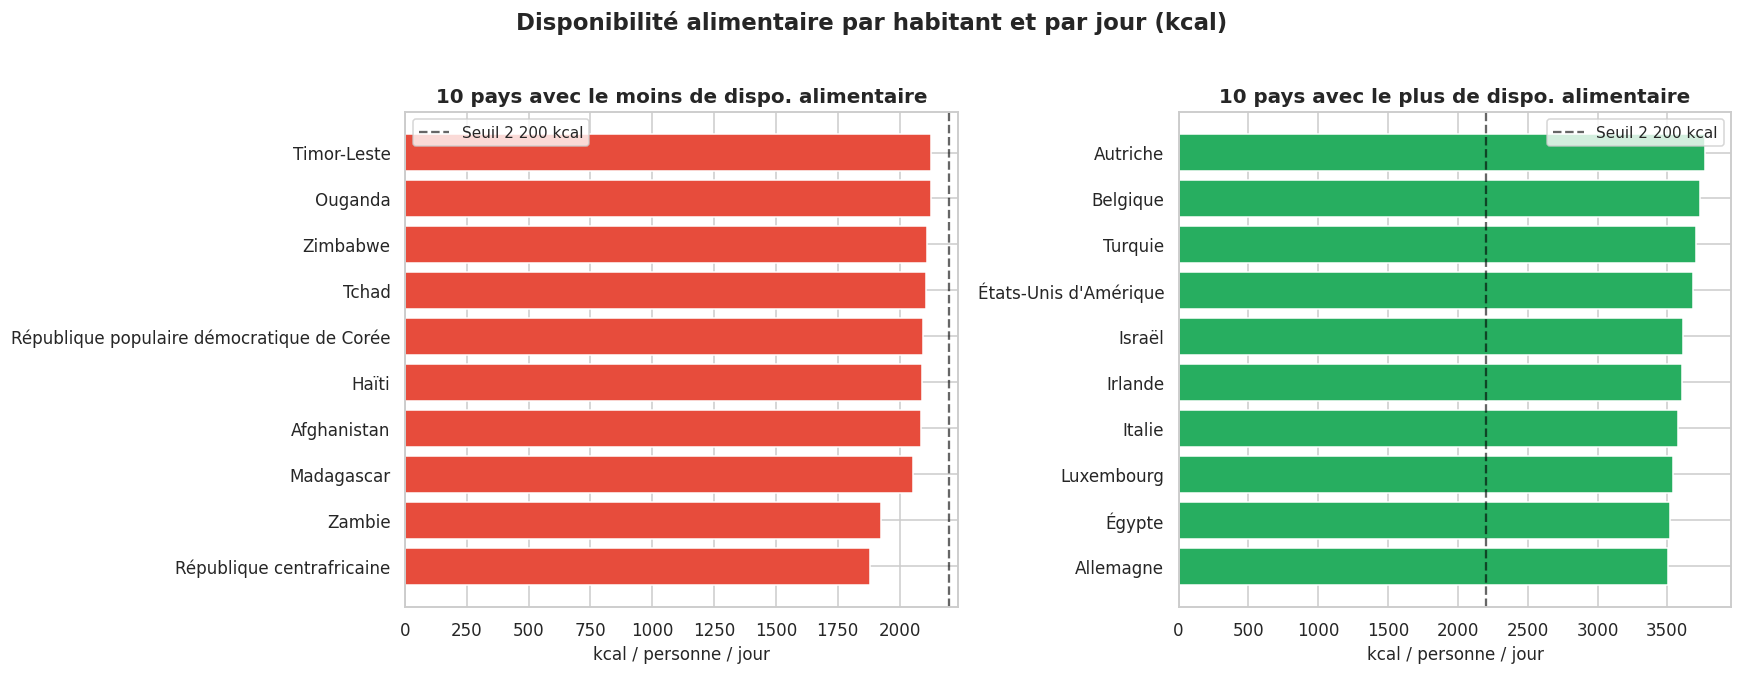

In [ ]:
dispo_kcal_par_pays = (
    dispo_alimentaire
    .groupby("Zone", as_index=False)["Disponibilité alimentaire (Kcal/personne/jour)"]
    .sum()
    .rename(columns={"Disponibilité alimentaire (Kcal/personne/jour)": "kcal_par_pers_par_jour"})
)

bottom10 = dispo_kcal_par_pays.nsmallest(10, "kcal_par_pers_par_jour")
top10    = dispo_kcal_par_pays.nlargest(10, "kcal_par_pers_par_jour")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bas
df_b = bottom10.sort_values("kcal_par_pers_par_jour")
axes[0].barh(df_b["Zone"], df_b["kcal_par_pers_par_jour"],
             color="#e74c3c", edgecolor="white")
axes[0].axvline(2200, color="black", linestyle="--", alpha=0.6, label="Seuil 2 200 kcal")
axes[0].set_xlabel("kcal / personne / jour", fontsize=11)
axes[0].set_title("10 pays avec le moins de dispo. alimentaire",
                  fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)

# Haut
df_t = top10.sort_values("kcal_par_pers_par_jour")
axes[1].barh(df_t["Zone"], df_t["kcal_par_pers_par_jour"],
             color="#27ae60", edgecolor="white")
axes[1].axvline(2200, color="black", linestyle="--", alpha=0.6, label="Seuil 2 200 kcal")
axes[1].set_xlabel("kcal / personne / jour", fontsize=11)
axes[1].set_title("10 pays avec le plus de dispo. alimentaire",
                  fontsize=13, fontweight="bold")
axes[1].legend(fontsize=10)

plt.suptitle("Disponibilité alimentaire par habitant et par jour (kcal)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

<div style="border:1px solid RGB(0,150,250);">
<h3 style="margin:auto;padding:20px;color:RGB(0,150,250);">3.11 – Cas d'étude : le Manioc en Thaïlande</h3>
</div>

La Thaïlande est le 1er exportateur mondial de manioc. Bien que sa population ne souffre pas de grave sous-nutrition, une proportion importante de la production est exportée plutôt que consommée localement. Nous calculons ici le pourcentage de production destiné à l'export.

In [ ]:
thai_manioc = dispo_alimentaire[
    (dispo_alimentaire["Zone"] == "Thaïlande") &
    (dispo_alimentaire["Produit"] == "Manioc")
].copy()

thai_manioc["pct_export"] = (
    thai_manioc["Exportations - Quantité"] / thai_manioc["Production"] * 100
).fillna(0)

total_prod   = thai_manioc["Production"].sum()
total_export = thai_manioc["Exportations - Quantité"].sum()
total_nourriture = thai_manioc["Nourriture"].sum()
total_autres = total_prod - total_export - total_nourriture
pct_export_global = total_export / total_prod * 100

print(f"Production totale de manioc (Thaïlande) : {total_prod/1e9:.2f} Md kg")
print(f"Exportée                                 : {pct_export_global:.1f} %")
print(f"Consommée localement (nourriture)        : {total_nourriture/total_prod*100:.1f} %")

Production totale de manioc (Thaïlande) : 30.23 Md kg
Exportée                                 : 83.4 %
Consommée localement (nourriture)        : 2.9 %


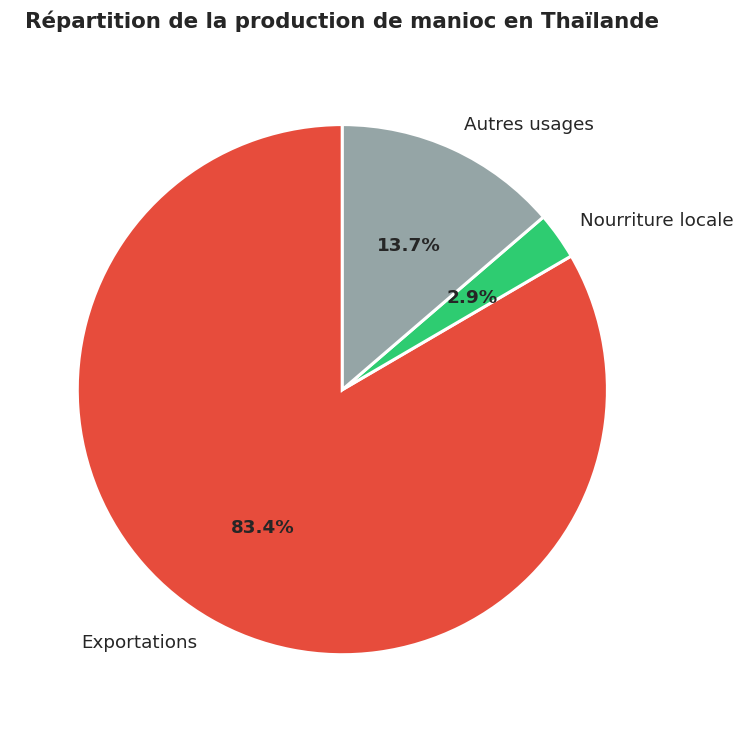

In [ ]:
# ── Graphique : usage du manioc thaïlandais ──
fig, ax = plt.subplots(figsize=(7, 7))
labels_thai = ["Exportations", "Nourriture locale", "Autres usages"]
vals_thai   = [total_export, total_nourriture, max(total_autres, 0)]
colors_thai = ["#e74c3c", "#2ecc71", "#95a5a6"]
wedges, texts, autotexts = ax.pie(
    vals_thai, labels=labels_thai, colors=colors_thai,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12}
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight("bold")
ax.set_title("Répartition de la production de manioc en Thaïlande",
             fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

<div style="background-color:RGB(0,150,250);">
<h2 style="margin:auto;padding:20px;color:#fff;">Étape 4 – Analyse complémentaire - Série temporelle de la sous-nutrition mondiale</h2>
</div>

Cette section exploite l'ensemble des plages temporelles disponibles dans le fichier  pour analyser l'évolution de la sous-alimentation dans le monde au fil du temps. Chaque entrée couvre une période de 3 ans (ex: 2014-2016) ; nous utilisons l'année médiane comme repère temporel.

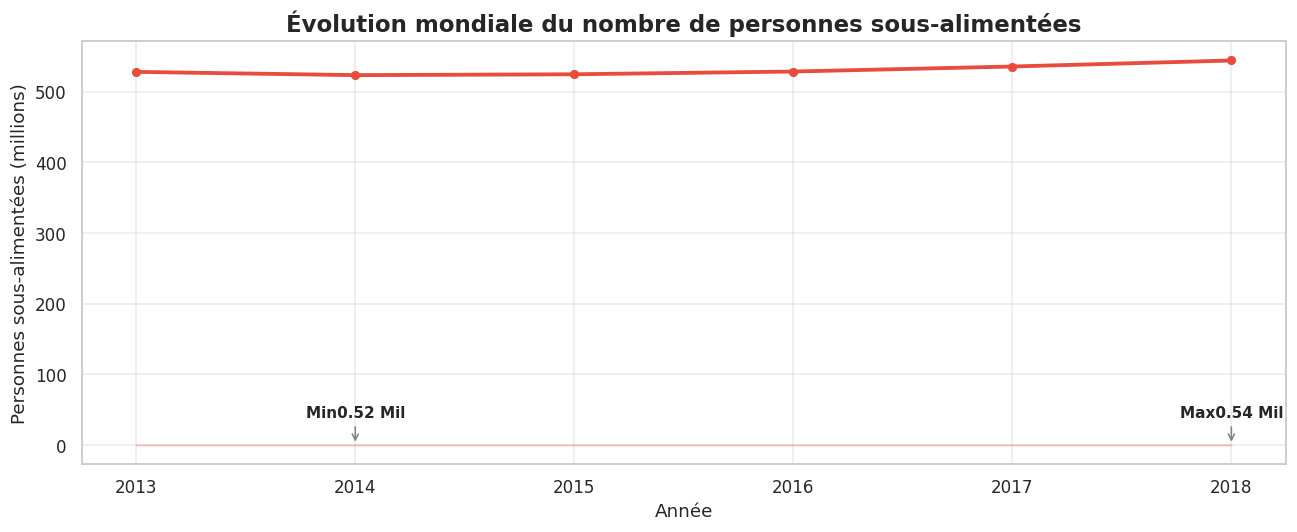

In [ ]:
# ── Évolution du nombre absolu de personnes sous-nourries dans le monde ──
evolution_mondiale = (
    sous_nutrition
    .groupby("annee_mid", as_index=False)["Sous_nutrition"]
    .sum()
    .sort_values("annee_mid")
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(evolution_mondiale["annee_mid"],
                evolution_mondiale["Sous_nutrition"] / 1e9,
                alpha=0.25, color="#e74c3c")
ax.plot(evolution_mondiale["annee_mid"],
        evolution_mondiale["Sous_nutrition"] / 1e6,
        color="#e74c3c", linewidth=2.5, marker="o", markersize=5)

# Annotation min & max
idx_min = evolution_mondiale["Sous_nutrition"].idxmin()
idx_max = evolution_mondiale["Sous_nutrition"].idxmax()
for idx, lbl in [(idx_min, "Min"), (idx_max, "Max")]:
    row = evolution_mondiale.loc[idx]
    ax.annotate(f"{lbl}{row['Sous_nutrition']/1e9:.2f} Mil",
                xy=(row["annee_mid"], row["Sous_nutrition"]/1e9),
                xytext=(0, 18), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("Personnes sous-alimentées (millions)", fontsize=12)
ax.set_title("Évolution mondiale du nombre de personnes sous-alimentées",
             fontsize=15, fontweight="bold")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

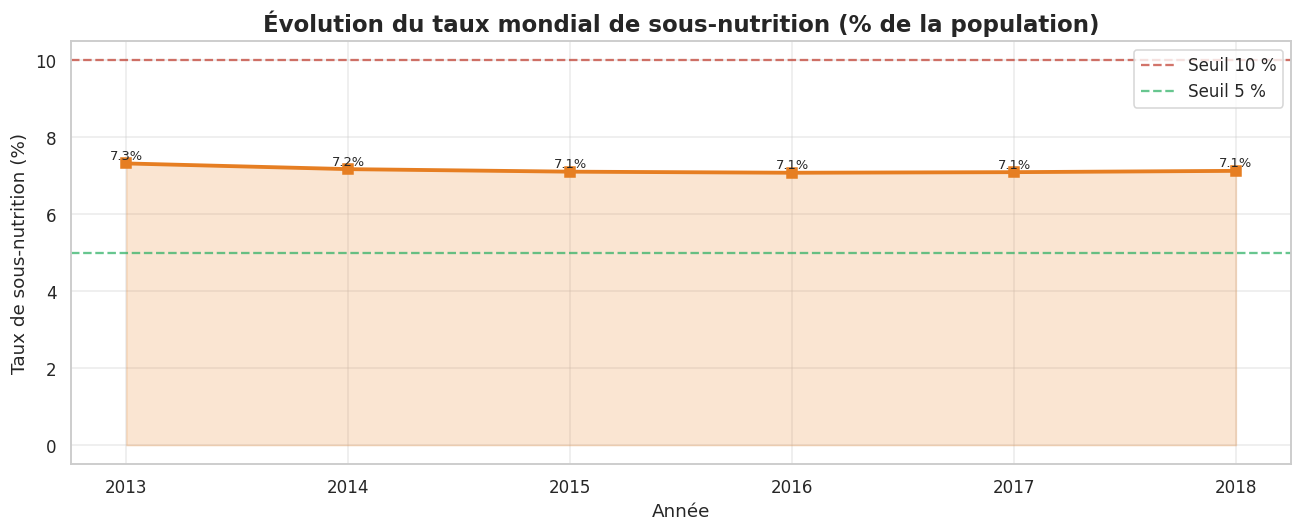

In [ ]:
# ── Évolution du taux mondial de sous-nutrition (%) ──
# Jointure avec la population pour chaque année médiane
evolution_taux = evolution_mondiale.merge(
    population.groupby("Année", as_index=False)["Valeur_harmonisee"].sum(),
    left_on="annee_mid", right_on="Année", how="inner"
)
evolution_taux["taux_pct"] = (
    evolution_taux["Sous_nutrition"] / evolution_taux["Valeur_harmonisee"] * 100
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(evolution_taux["annee_mid"], evolution_taux["taux_pct"],
                alpha=0.2, color="#e67e22")
ax.plot(evolution_taux["annee_mid"], evolution_taux["taux_pct"],
        color="#e67e22", linewidth=2.5, marker="s", markersize=6)
ax.axhline(10, color="#c0392b", linestyle="--", alpha=0.7, label="Seuil 10 %")
ax.axhline(5,  color="#27ae60", linestyle="--", alpha=0.7, label="Seuil 5 %")

for _, row in evolution_taux.iterrows():
    ax.text(row["annee_mid"], row["taux_pct"] + 0.1,
            f"{row['taux_pct']:.1f}%", ha="center", fontsize=8.5)

ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("Taux de sous-nutrition (%)", fontsize=12)
ax.set_title("Évolution du taux mondial de sous-nutrition (% de la population)",
             fontsize=15, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

<div style="background-color:RGB(0,150,250);">
<h2 style="margin:auto;padding:20px;color:#fff;">Étape 5 – Synthèse & conclusions</h2>
</div>

In [ ]:
print(f" Conclusion")
print(f"--------------------")
print("1-La production alimentaire mondiale est théoriquement suffisante")
print("   pour nourrir l'ensemble de la planète, y compris avec les seuls végétaux.")
print("2- Le problème est avant tout lié à la répartition,aux pertes, à l'utilisation des céréales pour l'élevage et aux inégalités d'accès à la nourriture.")

 Conclusion
--------------------
1-La production alimentaire mondiale est théoriquement suffisante
   pour nourrir l'ensemble de la planète, y compris avec les seuls végétaux.
2- Le problème est avant tout lié à la répartition,aux pertes, à l'utilisation des céréales pour l'élevage et aux inégalités d'accès à la nourriture.
